## Project - Crops Health Monitoring of Salinas valley,California using Hyperspectral Data.

The **WHAT** - AVIRIS atmospherically corrected hyperspectral data and ground truth labels of salinas valley, the *project* examines health of crops and plots the spectral signatures. 
Project includes total 3 Findings in total with RESULT I,II,III. which are 
1. Misclassification of two classes of crops (grapes and vinyard) 
2. NDVI and classification maps which tells us Which crops has less vegetation or bare soil.
3. Lettuce 4 classes (4,5,6,7 week) spectral signatures. In which there is one anomaly.

The **WHY** - Hyperspectral captures subtle changes in the environment which normal RGB and Multispectral can't do. Which can be used by farmers or insurance companies to detect early health concern of crops. As farmers can't do regular ground checkup on crops if the field is spread over several acres. So knowing NDVI and full classification data farmer can inspect those areas only where vegetation got compromised. 

The **PROCESS** - 
1. Loading data.
2. Deleting bad bands.
3. NDVI Calculate
4. Dimension Reduction using PCA.
5. Pipeline.
6. Ground truth plotting.
7. Random forest classification (96% accuracy , precision ,recall and f1 score also calculated).
8. Plotted confusion matrix to check visually the misclassification of class 8 and 15.
9. Classification map plotted which shows for all pixels not just test pixels.
10. SVM and KNN to check whether accuracy and other metrics improves or not.
11. RESULT I - Spectral signatures of class 8 and class 15.
12. NDVI map plotting.
13. RESULT II - Combined plotting of NDVI , ground truth and classification map
14. Lettuce crop monitoring for 4 different classes.
15. RESULT III - Spectral signatures for lettuce four classes.

In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

#### About the Data used 
Dowloaded AVIRIS Salinas data and its ground truth data @ https://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes
This scene was collected by the 224-band AVIRIS sensor over Salinas Valley, California, and is characterized by high spatial resolution (3.7-meter pixels). The area covered comprises 512 lines by 217 samples.It includes vegetables, bare soils, and vineyard fields. Salinas groundtruth contains 16 classes.


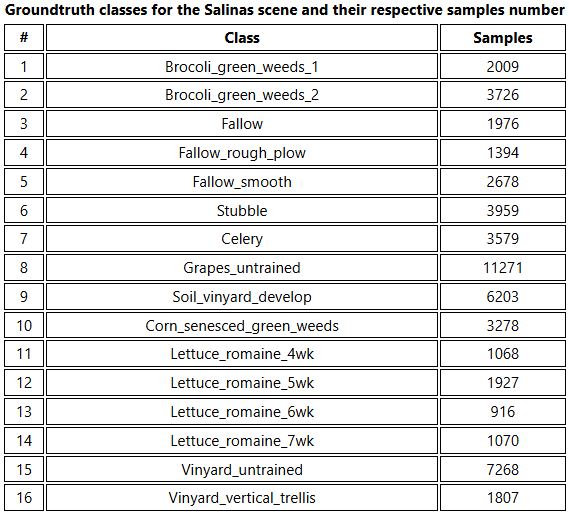



The data is in matlab format with .mat extentions as the data is archived in early 2000s where MATLAB is dominant in scientific computing. We are loading them using scipy library to convert to numpy arrays.
20 water absorption bands, in this case bands: [108-112], [154-167] were already discarded for water vapour effects to be eliminated, but we still do this process just in case.
Shape of hypercube is (512, 217, 185) - Hypercube is 3d array of pixels X, y and Wavelengths (bands)

In [3]:

def load_data(filepath):

    data = sio.loadmat(filepath)
    array_3d = data['salinas_corrected']
    return array_3d

array_3d = load_data('Salinas_corrected.mat')
print(array_3d.shape)

(512, 217, 204)


#### Deleting Bad bands
Function to getting clean data. We are deleting the very bands were already discarded in data but just to be on safer side I still did the deletion of bad bands which are mostly water vapour which can cause hindrance in actual reflectance values. In my old notebook of EDA this doesn't made much difference though and PCA later in book handles noisy data better anyway.

In [4]:
def preprocess(array_3d):
    correct_array = np.delete(array_3d, [108, 109, 110, 111, 112, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167 ], 2)
    return correct_array

cleaned = preprocess(array_3d)

#### NDVI Compute
NDVI is Normalized Difference Vegetation Index which tells us that where is dense vegetation land and where is water land/urban area.
NDVI always ranges from -1 to +1. But there isn’t a distinct boundary for each type of land cover.

For example, when you have negative values, it’s highly likely that it’s water(thats why removing any water content is necessary to get right values) On the other hand, if you have an NDVI value close to +1, there’s a high possibility that it’s dense green leaves.
But when NDVI is close to zero, there are likely no green leaves and it could even be an urbanized area.

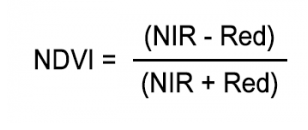

AVIRIS sensor captures light from 400nm to 2500nm spread across 224 bands. That means each band covers approximately:
(2500 - 400) / 224 = 9.4nm per band
Red light peaks at 670nm. To find which band that is:

Distance from start: 670 - 400 = 270nm
Band number: 270 / 9.4 = band 28

NIR peaks at 800nm:

Distance from start: 800 - 400 = 400nm
Band number: 400 / 9.4 = band 42

These are approximate — real AVIRIS has a wavelength lookup table but I don't have it for this dataset, so I calculated it manually.

In [5]:
def compute_ndvi(array_3d):
    nir = array_3d[:, :, 42].astype(float)
    red = array_3d[:, :, 28].astype(float)

    ndvi = (nir - red)/(nir + red)
    return ndvi

compute_ndvi(cleaned)

array([[-0.17334254, -0.18758621, -0.19005329, ...,  0.53971708,
         0.53857272,  0.53871201],
       [-0.17147826, -0.19795097, -0.19985058, ...,  0.54923492,
         0.5427335 ,  0.53871201],
       [-0.20700389, -0.18771862, -0.19463602, ...,  0.53988397,
         0.54486015,  0.54642534],
       ...,
       [ 0.5389778 ,  0.51903387,  0.51341301, ..., -0.23926812,
        -0.24142857, -0.23754513],
       [ 0.53113742,  0.53113742,  0.52260111, ..., -0.23926812,
        -0.24142857, -0.22467264],
       [ 0.52      ,  0.50609261,  0.47930345, ..., -0.22506925,
        -0.23531456, -0.22467264]], shape=(512, 217))

#### Dimension Reduction
Why Dimension reduction is necessary? Working with 185 bands is not practical as we easily get the most of variance of data in less bands possible for eg. 30 here. We are using PCA (Principal Component Analysis) for reduction to 30 components which are best representation of 185 bands. PCA needs flat 2d thats why we are reshaping our hypercube to 2d.

In [6]:

from sklearn.decomposition import PCA
def reduce_dims(array_3d, n_components):
    array_2d = array_3d.reshape(array_3d.shape[0] * array_3d.shape[1], array_3d.shape[2])
    pca = PCA(n_components)
    reduced_2d = pca.fit_transform(array_2d)  # This is our Features
    return reduced_2d

reduced = reduce_dims(cleaned, 30)
print(reduced.shape)

(111104, 30)


#### Pipleline
This pipeline takes raw hyperspectral data and produces three outputs — cleaned spectral data, NDVI map, and PCA-reduced features — ready for classification and analysis. Each step is a function so the entire workflow can be rerun cleanly on new data.

In [7]:
array_3d = load_data('Salinas_corrected.mat')
cleaned = preprocess(array_3d)
ndvi_map = compute_ndvi(cleaned)
reduced = reduce_dims(cleaned, 30)

print(cleaned.shape)
print(reduced.shape)

(512, 217, 185)
(111104, 30)


#### Ground Truth 
Salinas ground truth was created by people going into the field, identifying each crop by hand, and recording which pixels correspond to which crop class. Numbers 0-16, where 0 is unlabeled background. Refer to table at top for different classes of veggies.

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May 20 18:26:51 2011', '__version__': '1.0', '__globals__': [], 'salinas_gt': array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [16, 16, 16, ...,  0,  0,  0],
       [16, 16, 16, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(512, 217), dtype=uint8)}


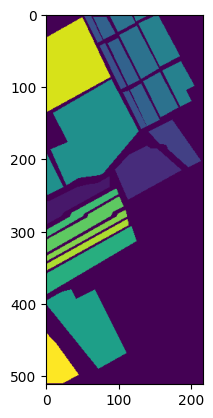

In [8]:
ground_truth = sio.loadmat('Salinas_gt.mat')
print(ground_truth)

ground_truth['salinas_gt'].shape
ground_truth_array = ground_truth['salinas_gt']
plt.imshow(ground_truth_array)


#### Random Forest Classfication
Random Forest uses bagging — it runs multiple decision trees simultaneously on distributed subsets of data and selects the class predicted by the majority. This reduces variance and makes it robust to noise, which is important in high-dimensional hyperspectral data where many bands carry redundant information. We filter out label 0 pixels (background/unlabeled) before training since they don't represent real crop classes. 80% of labeled pixels are used for training, 20% for testing. **96% accuracy** means the model correctly identifies the crop type for 96 out of 100 pixels — sufficient for field-level agricultural mapping.

Calculated precision, recall , f1 score and accuracy for all classes of crops.

In [9]:
ground_truth_array3d = ground_truth_array.reshape(ground_truth_array.shape[0] * ground_truth_array.shape[1])  #This is our target

print(ground_truth_array3d.shape)

trainingarray = ground_truth_array3d > 0
features = reduced[trainingarray]
target = ground_truth_array3d[trainingarray]

print(features.shape)
print(target.shape)

from sklearn.model_selection import train_test_split
X = features
y = target
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

classification_rep = classification_report(y_test, y_pred)
print(classification_rep)

(111104,)
(54129, 30)
(54129,)
0.957971549972289
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       395
           2       1.00      1.00      1.00       713
           3       0.99      1.00      1.00       389
           4       1.00      1.00      1.00       290
           5       1.00      1.00      1.00       517
           6       1.00      1.00      1.00       758
           7       1.00      1.00      1.00       713
           8       0.88      0.94      0.91      2295
           9       1.00      1.00      1.00      1268
          10       0.99      0.98      0.99       665
          11       0.98      0.99      0.99       213
          12       0.99      1.00      1.00       398
          13       0.99      1.00      1.00       194
          14       1.00      0.98      0.99       188
          15       0.90      0.80      0.84      1458
          16       1.00      1.00      1.00       372

    accuracy                   

#### Confusion Matrix
You can see above in classification report that f1 score of class 8 and class 15 are low which means that it is misclassifying those classes more than others (most crops are classified accurately).
In table **class 8** is **grape untrained** and **class 15** is **vinyard untrained** crops.
Why f1 score matters here - It is Harmonic Mean of Precision and Recall so it is essentially used to tell if there is class imbalance both 'False positives' and 'False negative' matter here. 
Confusion matrix plotted below that shows how model is classifying that particular classes interchangeably. Here index is from 0 so when you look at 7th row of x-axis which is class 8 and 14 th row of y-axis which class 15 - there is square which is outside the diagonal which tells you that **grapes are identified as vinyard or vice versa** for same faint square you see on 14th of x-axis and 7 row of y-axis.

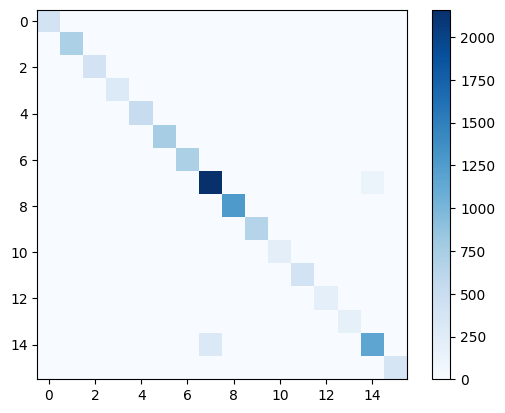

In [10]:

from sklearn.metrics import confusion_matrix
cfmatrix = confusion_matrix(y_test, y_pred)
plt.imshow(cfmatrix, cmap="Blues")
plt.savefig('confusion_matrix.png', dpi = 150, bbox_inches = 'tight')
plt.colorbar()

#### Classification Map
We are plotting image of field by classifying all pixels not just test pixels and compare them to the ground truth value map and we masking the zero classes as it is of now use because they are NOT crops.
You can see small dots of alternating colors of yellow and green over yellow and green patches of field at 0-100 of y-axis and 0-50 of x-axis in left map which is our full classification after reshaping them to 512, 217 as we needed an image to plot. 

(111104,)
(512, 217)
bool


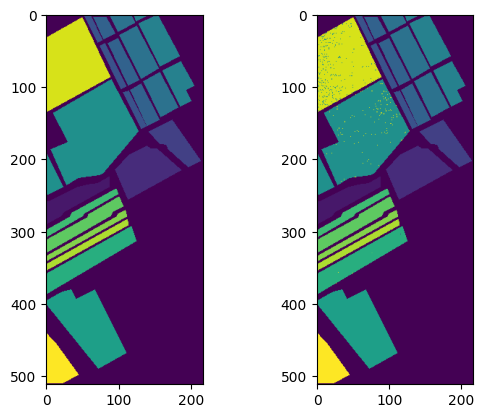

In [11]:

full_classification = rf.predict(reduced)
print(full_classification.shape)

reshaping_full_classification = full_classification.reshape(512, 217)
plt.subplot(1,2,1)
plt.imshow(ground_truth_array)
plt.subplot(1,2,2)
plt.imshow(reshaping_full_classification)

zero_array = ground_truth_array == 0
print(zero_array.shape)
print(zero_array.dtype)

reshaping_full_classification[zero_array] = 0
plt.subplot(1,2,1)
plt.imshow(ground_truth_array)
plt.subplot(1,2,2)
plt.imshow(reshaping_full_classification)


#### Support Vector Machine Classification
Just using another model to check whether accuracy and misclassification improves or not. SVM is used with standard scaler because it finds the hyperplanes to predict classes as sometime some features need scaling needed.

**FINDING** - Accuracy, F1 scores for class 8 and 15 are lower than Random Forest **NO IMPROVEMENTS**

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
svm = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(accuracy_svm)

classification_rep_svm = classification_report(y_test, y_pred_svm)
print(classification_rep_svm)

0.9531682985405505
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       395
           2       1.00      1.00      1.00       713
           3       1.00      1.00      1.00       389
           4       1.00      1.00      1.00       290
           5       1.00      1.00      1.00       517
           6       1.00      1.00      1.00       758
           7       1.00      1.00      1.00       713
           8       0.86      0.93      0.90      2295
           9       1.00      1.00      1.00      1268
          10       1.00      0.98      0.99       665
          11       0.99      1.00      1.00       213
          12       1.00      1.00      1.00       398
          13       1.00      1.00      1.00       194
          14       0.99      0.99      0.99       188
          15       0.88      0.77      0.82      1458
          16       1.00      1.00      1.00       372

    accuracy                           0.95     10826
   macr

#### KNearest Neighbors Classification
Same story with KNN also 
**FINDING** - Accuracy, F1 scores for class 8 and class 15 are lower than svm and Random Forest. **NO IMPROVEMENTS**

In [13]:
from sklearn.neighbors import KNeighborsClassifier

svm = make_pipeline(StandardScaler(), SVC(gamma='auto'))
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(accuracy_knn)

classification_rep_knn = classification_report(y_test, y_pred_knn)
print(classification_rep_knn)

0.9206539811564751
              precision    recall  f1-score   support

           1       1.00      0.99      0.99       395
           2       0.99      1.00      1.00       713
           3       0.98      1.00      0.99       389
           4       1.00      1.00      1.00       290
           5       1.00      0.99      0.99       517
           6       1.00      1.00      1.00       758
           7       1.00      1.00      1.00       713
           8       0.82      0.84      0.83      2295
           9       0.99      1.00      0.99      1268
          10       0.96      0.95      0.95       665
          11       0.96      1.00      0.98       213
          12       0.99      1.00      0.99       398
          13       0.98      0.99      0.99       194
          14       0.97      0.97      0.97       188
          15       0.75      0.70      0.72      1458
          16       1.00      1.00      1.00       372

    accuracy                           0.92     10826
   macr

#### RESULT I 
**Grapes and vinyard spectral signatures** 
Their spectral signatures should look similar based on our confusion matrix. Plotting them.
Why model finds difficulty to classify them ? - both are vine crops growing in similar soil conditions in the same valley. Untrained grapes and untrained vineyard have similar leaf structure, similar canopy gaps, similar soil exposure. The spectral difference is subtle enough that 185 bands still can't cleanly separate them.

11271
7268


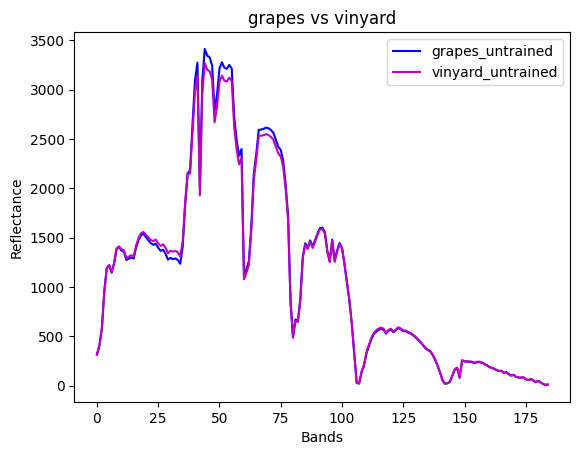

In [24]:
grapes_untrained = ground_truth_array3d == 8
print(grapes_untrained.sum())

vinyard_untrained = ground_truth_array3d == 15
print(vinyard_untrained.sum())

cleaned2d = cleaned.reshape( cleaned.shape[0] * cleaned.shape[1], cleaned.shape[2])
cleaned2d.shape

# Mean of Grapes
cleanedgrapes = cleaned2d[grapes_untrained]
cleanedgrapes.shape

grapesmean = cleanedgrapes.mean(axis=0)

# Mean of vinyard
cleanedvinyard = cleaned2d[vinyard_untrained]
cleanedvinyard.shape

vinyardmean = cleanedvinyard.mean(axis=0)

plt.plot(grapesmean, color = 'b', label = 'grapes_untrained')
plt.plot(vinyardmean, color = 'm', label = 'vinyard_untrained')
plt.xlabel("Bands")
plt.ylabel("Reflectance")
plt.title("grapes vs vinyard")
plt.legend()
plt.show()

#### NDVI Map
Our calculated NDVI plotting. 
**RED** is mostly 0 class and **GREEN** is dense vegetation(eg.lettuce) and Vegetation is less (Red color) near our patch where our grape and vinyard crops are. Crops most likely are healthy but the reason their NDVI is low is that untrained vines have gaps between plants exposing bare soil, which lowers NDVI even in healthy crops. 

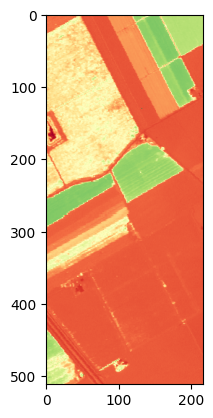

In [14]:
plt.savefig('ndvi.png', dpi = 150, bbox_inches = 'tight')
plt.imshow(ndvi_map, cmap = 'RdYlGn')

#### RESULT II
Here are three important images which are our findings - ground truth, classification map and NDVI. 

**What can farmer/beneficary get from this is that?** - 

1. Classification map — confirms which crop is where without manual inspection across the entire field.

2. NDVI map — shows which patches have lower vegetation density than expected, flagging areas to inspect on the ground.

3. Combined — if a patch is classified as lettuce 6wk but has NDVI similar to lettuce 4wk, that field is behind schedule and needs attention.

A farmer managing 500 acres cannot walk every row. This gives them a map that says "go check these 3 patches, something is wrong there."

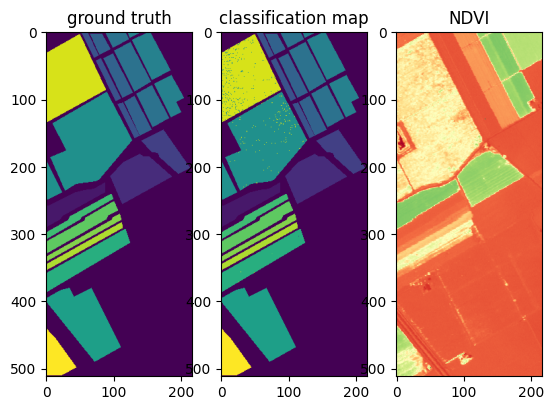

In [15]:

plt.subplot(1,3,1)
plt.imshow(ground_truth_array)
plt.title("ground truth")
plt.subplot(1, 3, 2)
plt.imshow(reshaping_full_classification)
plt.title("classification map")
plt.subplot(1,3,3)
plt.imshow(ndvi_map, cmap = 'RdYlGn')
plt.title("NDVI")
plt.savefig('results.png', dpi = 150, bbox_inches = 'tight')

#### Lettuce 4wk, 5wk, 6wk & 7wk Crop Monitoring 
Check whether our lettuce crops are healthy are not. There are 4 classes of lattuce on weekly growth basis - 4,5,6 and 7.

We are extracting reflectance values for those 4 classes , averaging them and plotting them.
**What is expected?** NIR (bands near 50 to 100) should increase in order following 4th week as lowest and 7th week as highest. As NIR is tells us about canopy. Growing lettuce will reflect more with each upcoming week showing dense vegetation so increased NIR.

In [ ]:
lettuce4 = ground_truth_array3d == 11
print(lettuce4.sum())

lettuce5 = ground_truth_array3d == 12
print(lettuce5.sum())

lettuce6 = ground_truth_array3d == 13
print(lettuce6.sum())

lettuce7 = ground_truth_array3d == 14
print(lettuce7.sum())


1068
1927
916
1070


(111104, 185)

In [25]:
cleanedlettuce4 = cleaned2d[lettuce4]
cleanedlettuce4.shape

lettuce4mean = cleanedlettuce4.mean(axis=0)

In [26]:
cleanedlettuce5 = cleaned2d[lettuce5]
cleanedlettuce5.shape


lettuce5mean = cleanedlettuce5.mean(axis=0)

In [27]:
cleanedlettuce6 = cleaned2d[lettuce6]
cleanedlettuce6.shape


lettuce6mean = cleanedlettuce6.mean(axis=0)

In [28]:
cleanedlettuce7 = cleaned2d[lettuce7]
cleanedlettuce7.shape


lettuce7mean = cleanedlettuce7.mean(axis=0)

#### RESULT III
**Lettuce Spectral signatures (4,5,6,7 week)**
There is no pattern in signatures. Light is reflected differently by all four classes with different wavelength range - 

**Why is that so?**

Bands 0-40 (visible ~400-780nm):
Week 7 lettuce has a large dense canopy — but dense canopy also means more leaf overlap and shadowing. Younger lettuce (4wk) has smaller, flatter individual leaves with less self-shadowing, which can reflect more visible light per unit. Also older leaves have more structural complexity that absorbs more visible light for photosynthesis.

NIR (bands 40-75) — Interacts with leaf cell structure and canopy density. More leaves = more NIR reflection. 7wk wins here clearly. But 5th week is lower than 4th week here which is **anomoly* which needs ground observation.

Bands 100-180 (SWIR ~1340-2100nm):
SWIR measures water content and dry matter. Younger lettuce leaves have higher water content relative to their size — they're mostly water. Older lettuce has more dry matter, cell walls, structural compounds. These absorb SWIR differently, and the relationship isn't linear with age.

However band numbers are approximate — exact wavelength validation requires the full AVIRIS metadata file which was not available in this dataset.

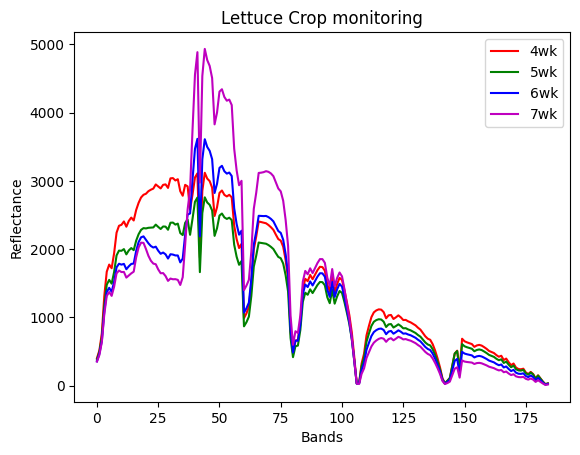

In [29]:
plt.plot(lettuce4mean, color = 'r', label = '4wk')
plt.plot(lettuce5mean, color = 'g', label = '5wk')
plt.plot(lettuce6mean, color = 'b', label = '6wk')
plt.plot(lettuce7mean, color = 'm', label = '7wk')
plt.xlabel("Bands")
plt.ylabel("Reflectance")
plt.title("Lettuce Crop monitoring")
plt.legend()
plt.savefig('lettuce_monitoring.png', dpi = 150, bbox_inches = 'tight')
plt.show()